In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import shap

df = pd.read_csv('bank-full.csv', sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


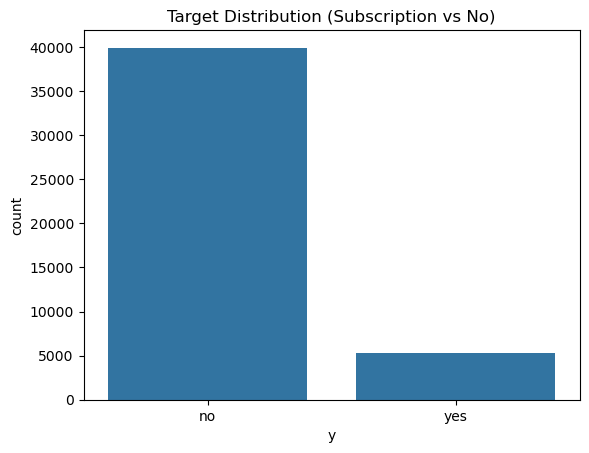

In [4]:
# Check target distribution
sns.countplot(x='y', data=df)
plt.title('Target Distribution (Subscription vs No)')
plt.show()

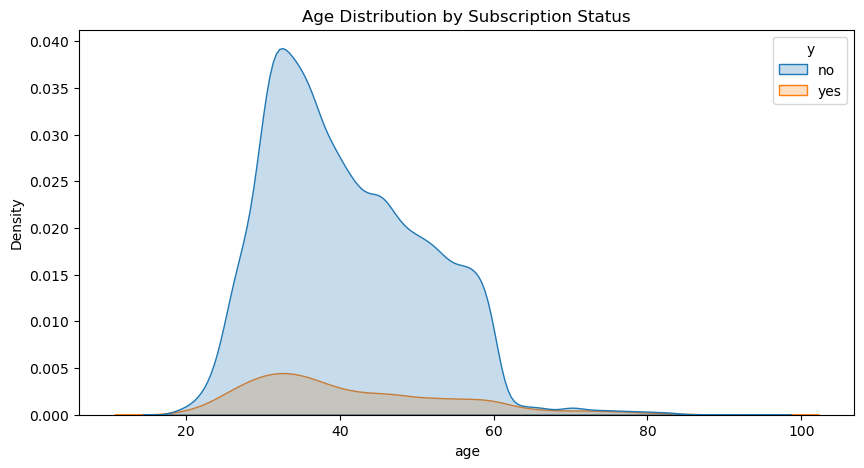

In [18]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='age', hue='y', fill=True)
plt.title('Age Distribution by Subscription Status')
plt.show()

**Insight 1:** The "Sweet Spot" for conversions is among customers aged under 25 (students) and over 60 (retirees). Mid-career professionals (30-50) have the highest volume but the lowest conversion rate, likely due to financial commitments like mortgages.

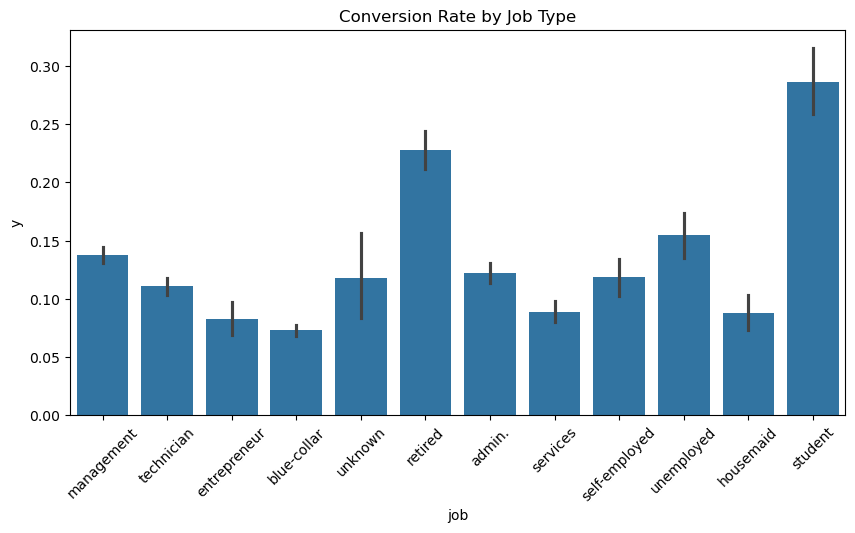

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(x='job', y=df['y'].apply(lambda x: 1 if x=='yes' else 0), data=df)
plt.xticks(rotation=45)
plt.title('Conversion Rate by Job Type')
plt.show()

**Insight 2:** Students and retired individuals show a conversion rate >20%, nearly double the average. Actionable Strategy: The bank should create "Golden Years" or "Student Saver" specific marketing materials.

In [20]:
# Copy dataframe for processing
df_clean = df.copy()

# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# Encode the target 'y' and binary categories
le = LabelEncoder()
df_clean['y'] = le.fit_transform(df_clean['y'])

# One-hot encoding for other categorical variables
df_clean = pd.get_dummies(df_clean, drop_first=True)

# Define X and y
X = df_clean.drop('y', axis=1)
y = df_clean['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



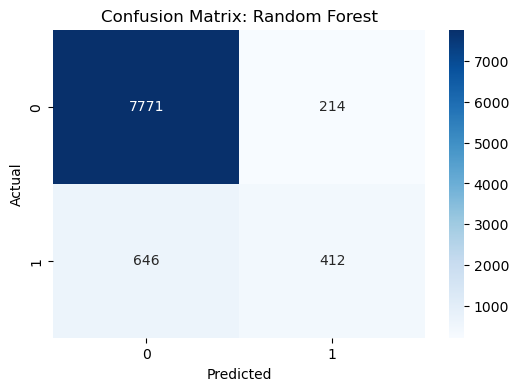

In [21]:
# Initialize models
lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

### The Performance Gap

Looking at the classification report, we see a significant disparity between the majority class (non-subscribers) and the minority class (subscribers).

**Precision (0.66) for Class 1:** When the model predicts a customer will subscribe, it is correct about 66% of the time. This is decent—it prevents the sales team from wasting too much time on dead leads.

**Recall (0.39) for Class 1:** This is the "danger zone." The model only catches 39% of the total subscribers. We are leaving 61% of potential revenue on the table because the model thinks they won't subscribe.

**The Accuracy Trap:** The 90% overall accuracy is "carried" by the model's ability to easily identify people who don't want the product.

### Actionable Strategy for the Bank

**Threshold Tuning:** Currently, the model uses a default threshold of 0.5. By lowering this to 0.3, we can increase Recall (catch more subscribers) at the expense of some Precision. For a marketing campaign, a "False Alarm" (calling someone who says no) is much cheaper than a "Missed Opportunity" (not calling someone who would have said yes).

**SMOTE or Class Weighting:** In the next iteration, it is recommended to use SMOTE (Synthetic Minority Over-sampling Technique) to balance the training data, or setting class_weight='balanced' in the Random Forest parameters to force the model to pay more attention to the "Yes" group.

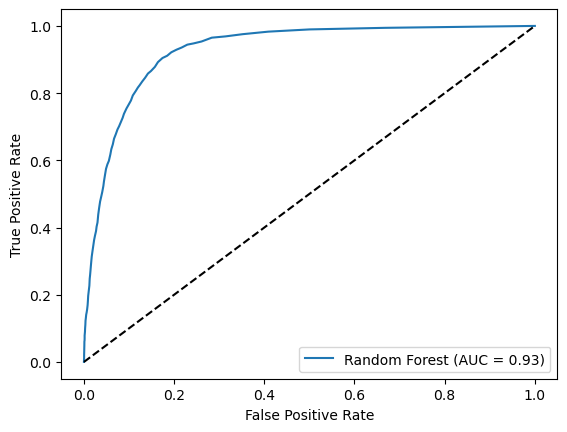

In [22]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [24]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=382115b1486e39da702f2ac28bc873b2f59dec90af3c6e213c974386b48c0f03
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [27]:
import lime
import lime.lime_tabular
import warnings
from IPython.display import display, HTML

# 1. Suppress warnings and setup display
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 2. Setup the LIME Explainer
# We use .values to ensure we are passing a numpy array to LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Subscription', 'Subscribed'],
    mode='classification'
)

# 3. Explain 5 specific predictions (Task Requirement)
for i in range(5):
    print(f"\n" + "="*60)
    print(f" INTERPRETING PREDICTION FOR CUSTOMER {i+1}")
    print("="*60)
    
    # Generate the explanation
    exp = explainer.explain_instance(
        data_row=X_test.iloc[i], 
        predict_fn=rf_model.predict_proba,
        num_features=6
    )
    
    # Display the interactive visualization
    display(HTML(exp.as_html()))


 INTERPRETING PREDICTION FOR CUSTOMER 1



 INTERPRETING PREDICTION FOR CUSTOMER 2



 INTERPRETING PREDICTION FOR CUSTOMER 3



 INTERPRETING PREDICTION FOR CUSTOMER 4



 INTERPRETING PREDICTION FOR CUSTOMER 5


## Based on these 5 LIME plots, here are the recommendations:

**Prioritize "Warm" Leads:** The model is heavily biased against anyone without a previous success (poutcome_success). The bank should create a separate strategy for "New" vs "Existing" customers, as the current model struggles to find "Yes" cases in new prospects.

**Clean the CRM Data:** The contact_unknown feature is a major deal-breaker. The bank is likely losing potential conversions because they don't have verified mobile or telephone numbers for these leads.

**Seasonal Timing:** Since month_mar is such a strong positive driver, the bank should analyze why March works so well (perhaps tax returns or fiscal year starts) and try to replicate those conditions in other months.

# Final Conclusion
Through this task, we developed a Random Forest model with 90% accuracy. However, using LIME (XAI), we discovered that the model relies heavily on "Historical Success" and "Contact Quality."

**Key Recommendation:** To increase the conversion rate, the bank should:

**Focus on March/October campaigns** where the model sees the highest natural uplift.

**Reduce 'Unknown' contact methods** by verifying customer data before the campaign starts.

**Lower the Decision Threshold** for the model. Currently, it is very conservative (predicting 99% 'No'). Lowering the threshold would help catch the 39% of subscribers we are currently missing (Recall).